Cargando el modelo y preparando el entorno...
Preparando la imagen del último trimestre...
Descargando datos de la imagen... Esto puede tardar.
Clasificando los píxeles localmente...
Visualizando el mapa de resultados...


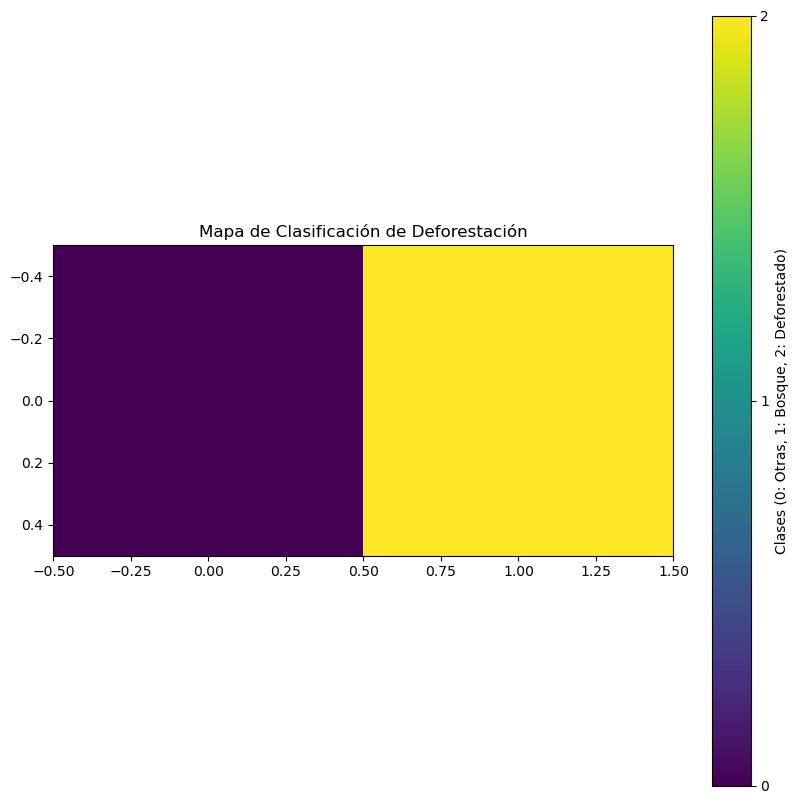

Guardando el resultado como GeoTIFF...

¡Proceso completado! Mapa guardado como 'deforestation_map_Q3_2025.tif'


In [5]:
import ee
import geemap
import joblib
import numpy as np
import rasterio
from rasterio.transform import from_bounds
import matplotlib.pyplot as plt
import pandas as pd

# --- PASO 1: CARGAR MODELO Y PREPARAR ENTORNO GEE ---
print("Cargando el modelo y preparando el entorno...")
model_filename = 'deforestation_model_v1.pkl'
classifier = joblib.load(model_filename)

ee.Initialize(project="ee-gis-scode") # Reemplaza con tu EE Project ID

xmin, ymin, xmax, ymax = -79.350128, -2.992413, -78.932648, -2.720840
cuenca_aoi = ee.Geometry.Rectangle([xmin, ymin, xmax, ymax])

# --- PASO 2: OBTENER LA IMAGEN DE GEE ---
print("Preparando la imagen del último trimestre...")
start_date, end_date = '2025-07-01', '2025-09-30'

sentinel_collection = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED').filterDate(start_date, end_date).filterBounds(cuenca_aoi)

def maskS2clouds(image):
    qa = image.select('QA60')
    mask = qa.bitwiseAnd(1 << 10).eq(0).And(qa.bitwiseAnd(1 << 11).eq(0))
    return image.updateMask(mask).divide(10000)

median_composite = sentinel_collection.map(maskS2clouds).median().clip(cuenca_aoi)
ndvi = median_composite.normalizedDifference(['B8', 'B4']).rename('NDVI')
inference_image = median_composite.addBands(ndvi).select(
    ['B2', 'B3', 'B4', 'B8', 'NDVI'], # <-- Bandas originales
    ['Blue', 'Green', 'Red', 'NIR', 'NDVI'] # <-- Nuevos nombres que coinciden con el entrenamiento
)

# --- PASO 3: DESCARGAR DATOS DE LA IMAGEN COMO NUMPY ARRAY ---
print("Descargando datos de la imagen... Esto puede tardar.")
# geemap.ee_to_numpy convierte la imagen de GEE a un array local
img_data = geemap.ee_to_numpy(inference_image, region=cuenca_aoi)
# img_data tiene una forma de (altura, anchura, 5 bandas)

# --- PASO 4: PREPARAR DATOS Y CLASIFICAR LOCALMENTE ---
print("Clasificando los píxeles localmente...")
# Scikit-learn espera un array 2D (n_pixeles, n_bandas)
# Guardamos las dimensiones originales para después
h, w, d = img_data.shape
# Aplanamos el array
pixels_2d = img_data.reshape(-1, d)

# Eliminar píxeles con datos nulos (si los hay)
pixels_df = pd.DataFrame(pixels_2d, columns=['Blue', 'Green', 'Red', 'NIR', 'NDVI']).dropna()
# Realizar la predicción
predictions = classifier.predict(pixels_df)

# Crear una imagen vacía y rellenarla con las predicciones
# Llenamos con -1 para ver si quedan huecos
classified_image_1d = np.full(h * w, -1, dtype=np.int8)
classified_image_1d[pixels_df.index] = predictions

# Volver a la forma original de la imagen (altura, anchura)
classification_result = classified_image_1d.reshape(h, w)

# --- PASO 5: VISUALIZAR EL MAPA DE RESULTADOS ---
print("Visualizando el mapa de resultados...")
plt.figure(figsize=(10, 10))
plt.imshow(classification_result, cmap='viridis') # Usar un colormap para visualizar
plt.title("Mapa de Clasificación de Deforestación")
plt.colorbar(ticks=[0, 1, 2], label="Clases (0: Otras, 1: Bosque, 2: Deforestado)")
plt.show()

# --- PASO 6: GUARDAR EL RESULTADO COMO GEOTIFF ---
print("Guardando el resultado como GeoTIFF...")
# Necesitamos la información geoespacial para guardar correctamente el archivo
transform = from_bounds(xmin, ymin, xmax, ymax, w, h)
output_geotiff = 'deforestation_map_Q3_2025.tif'

with rasterio.open(
    output_geotiff,
    'w',
    driver='GTiff',
    height=h,
    width=w,
    count=1, # una sola banda de salida
    dtype=classification_result.dtype,
    crs='EPSG:4326', # Sistema de coordenadas
    transform=transform,
) as dst:
    dst.write(classification_result, 1)

print(f"\n¡Proceso completado! Mapa guardado como '{output_geotiff}'")